In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RAW_FILE = Path("data/raw/final_merged_data.csv")
OUTPUT_DIR = Path("data/preprocessed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

raw_df = pd.read_csv(RAW_FILE)

print(raw_df.shape)
print(raw_df.columns.tolist())
raw_df.head()

(24085, 20)
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'Participant']


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,Participant
0,1.613036e+12,NaN,[LogManager] Application Started,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P10
1,1.613036e+12,NaN,[UnityRecordSection@10Hz],Recorder added : TransformRecorder:Player,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P10
2,1.613036e+12,NaN,[UnityRecordSection@10Hz],Recorder added : LogEventIDRecorder,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P10
3,1.613036e+12,NaN,[ExperimentManager] Session changed to: S0_Exp...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P10
4,1.613036e+12,1.0,[ S0_Exploration ] Pause ON,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P10


In [2]:
relevant_events = [
    "Stimuli Presentation",
    "Memory Quiz Response",
    "Stimuli Placed",
    "Memory Placement confidence",
    "Memory Quiz2 Response",
    "Memory Quiz2 confidence",
]

df_events = raw_df[
    raw_df["V3"].astype(str).str.contains("|".join(relevant_events), na=False)
].copy()

print(df_events.shape)
df_events[["Participant", "V1", "V3", "V4", "V6", "V10"]].head(30)

(13440, 20)


,Participant,V1,V3,V4,V6,V10
17,P10,1.613036e+12,[ S3_Memory ] Stimuli Presentation,food_2_e1_11_nr_o_v1_old,nr,NaN
19,P10,1.613036e+12,[ S3_Memory ] Memory Quiz Response,seen,NaN,NaN
22,P10,1.613036e+12,[ S3_Memory ] Stimuli Placed,food_2_e1_11_nr_o_v1_old,nr,Distance : 222.2831
23,P10,1.613036e+12,[ S3_Memory ] Memory Placement confidence,23,NaN,NaN
25,P10,1.613036e+12,[ S3_Memory ] Memory Quiz2 Response,two_weeks,NaN,NaN
26,P10,1.613036e+12,[ S3_Memory ] Memory Quiz2 confidence,37,NaN,NaN
27,P10,1.613036e+12,[ S3_Memory ] Stimuli Presentation,drink_11_memo,ne,NaN
29,P10,1.613036e+12,[ S3_Memory ] Memory Quiz Response,not_seen,NaN,NaN
32,P10,1.613036e+12,[ S3_Memory ] Stimuli Placed,drink_11_memo,ne,Distance : 1118.311
33,P10,1.613036e+12,[ S3_Memory ] Memory Placement confidence,100,NaN,NaN


In [3]:
trials = []
current_trial = {}

for _, row in df_events.iterrows():
    event = str(row["V3"])

    if "Stimuli Presentation" in event:
        if current_trial:
            trials.append(current_trial)

        current_trial = {
            "Participant": row["Participant"],
            "timestamp": row["V1"],
            "stimulus": row["V4"],
            "stimulus_cat_raw": row["V6"],
        }

    elif "Memory Quiz Response" in event:
        current_trial["recognition_response"] = row["V4"]

    elif "Stimuli Placed" in event:
        try:
            dist_str = str(row["V10"])
            distance = float(dist_str.split(":")[1].strip())
        except Exception:
            distance = np.nan

        current_trial["placement_distance"] = distance
        current_trial["placement_raw_V4"] = row["V4"]
        current_trial["placement_raw_V6"] = row["V6"]
        current_trial["placement_raw_V10"] = row["V10"]

    elif "Memory Placement confidence" in event:
        current_trial["placement_confidence"] = row["V4"]

    elif "Memory Quiz2 Response" in event:
        current_trial["temporal_response"] = row["V4"]

    elif "Memory Quiz2 confidence" in event:
        current_trial["temporal_confidence"] = row["V4"]

if current_trial:
    trials.append(current_trial)

mem = pd.DataFrame(trials)

print(mem.shape)
mem.head(20)

(2240, 12)


,Participant,timestamp,stimulus,stimulus_cat_raw,recognition_response,placement_distance,placement_raw_V4,placement_raw_V6,placement_raw_V10,placement_confidence,temporal_response,temporal_confidence
0,P10,1.613036e+12,food_2_e1_11_nr_o_v1_old,nr,seen,222.283100,food_2_e1_11_nr_o_v1_old,nr,Distance : 222.2831,23,two_weeks,37
1,P10,1.613036e+12,drink_11_memo,ne,not_seen,1118.311000,drink_11_memo,ne,Distance : 1118.311,100,never,100
2,P10,1.613036e+12,wealth_6_e2_15_r_o_v1_old,re,seen,543.870500,wealth_6_e2_15_r_o_v1_old,re,Distance : 543.8705,4,yesterday,46
3,P10,1.613037e+12,pirate_2_e3_11_nr_h_v1_old,nr,not_seen,754.491100,pirate_2_e3_11_nr_h_v1_old,nr,Distance : 754.4911,78,never,78
4,P10,1.613037e+12,viking_8_e3_16_nr_h_v1_old,nr,not_seen,745.093800,viking_8_e3_16_nr_h_v1_old,nr,Distance : 745.0938,32,never,21
5,P10,1.613037e+12,food_12_memo,ne,not_seen,1268.135000,food_12_memo,ne,Distance : 1268.135,100,never,100
6,P10,1.613037e+12,pirate_7_e3_1_nr_h_v1_old,nr,seen,0.952219,pirate_7_e3_1_nr_h_v1_old,nr,Distance : 0.9522193,78,two_weeks,82
7,P10,1.613037e+12,wealth_8_e2_14_r_o_v1_old,re,not_seen,1113.542000,wealth_8_e2_14_r_o_v1_old,re,Distance : 1113.542,67,never,74
8,P10,1.613037e+12,pirate_5_e1_7_nr_h_v1_old,nr,seen,348.247200,pirate_5_e1_7_nr_h_v1_old,nr,Distance : 348.2472,18,one_week,35
9,P10,1.613037e+12,viking_7_e1_13_r_h_v1_old,re,not_seen,1189.011000,viking_7_e1_13_r_h_v1_old,re,Distance : 1189.011,57,never,64


In [4]:
def parse_stimulus_name(filename):
    """
    Parse names like:
    food_2_e1_11_nr_o_v1_old
    drink_11_memo
    """
    name = str(filename).replace(".jpg", "")
    parts = name.split("_")

    # Old encoded stimuli:
    # category_list_encoding_checkpoint_relevance_h/o_version_old
    if "old" in parts and len(parts) >= 8:
        return pd.Series({
            "stim_cat": parts[0],
            "list_no": parts[1],
            "encoding_session": parts[2],
            "checkpoint": parts[3],
            "relevance": parts[4],
            "human_object": parts[5],
            "version": parts[6],
            "old_new": parts[7],
        })

    # Memory-task novel items seem to be like drink_11_memo
    if "memo" in parts:
        return pd.Series({
            "stim_cat": parts[0] if len(parts) > 0 else np.nan,
            "list_no": np.nan,
            "encoding_session": np.nan,
            "checkpoint": parts[1] if len(parts) > 1 else np.nan,
            "relevance": np.nan,
            "human_object": np.nan,
            "version": np.nan,
            "old_new": "new_memory",
        })

    # Fallback
    return pd.Series({
        "stim_cat": parts[0] if len(parts) > 0 else np.nan,
        "list_no": np.nan,
        "encoding_session": np.nan,
        "checkpoint": parts[1] if len(parts) > 1 else np.nan,
        "relevance": np.nan,
        "human_object": np.nan,
        "version": np.nan,
        "old_new": np.nan,
    })


parsed = mem["stimulus"].apply(parse_stimulus_name)
mem = pd.concat([mem, parsed], axis=1)

mem["participant_id"] = (
    mem["Participant"]
    .astype(str)
    .str.replace("P", "", regex=False)
    .astype(int)
)

mem["is_old"] = mem["old_new"].eq("old")
mem["is_new_memory"] = mem["old_new"].eq("new_memory")
mem["is_relevant"] = mem["relevance"].map({"r": True, "nr": False})
mem["is_human"] = mem["human_object"].map({"h": True, "o": False})

for col in ["placement_distance", "placement_confidence", "temporal_confidence"]:
    mem[col] = pd.to_numeric(mem[col], errors="coerce")

print(mem.shape)
mem.head(20)

(2240, 25)


,Participant,timestamp,stimulus,stimulus_cat_raw,recognition_response,placement_distance,placement_raw_V4,placement_raw_V6,placement_raw_V10,placement_confidence,...,checkpoint,relevance,human_object,version,old_new,participant_id,is_old,is_new_memory,is_relevant,is_human
0,P10,1.613036e+12,food_2_e1_11_nr_o_v1_old,nr,seen,222.283100,food_2_e1_11_nr_o_v1_old,nr,Distance : 222.2831,23,...,11,nr,o,v1,old,10,True,False,False,False
1,P10,1.613036e+12,drink_11_memo,ne,not_seen,1118.311000,drink_11_memo,ne,Distance : 1118.311,100,...,11,NaN,NaN,NaN,new_memory,10,False,True,NaN,NaN
2,P10,1.613036e+12,wealth_6_e2_15_r_o_v1_old,re,seen,543.870500,wealth_6_e2_15_r_o_v1_old,re,Distance : 543.8705,4,...,15,r,o,v1,old,10,True,False,True,False
3,P10,1.613037e+12,pirate_2_e3_11_nr_h_v1_old,nr,not_seen,754.491100,pirate_2_e3_11_nr_h_v1_old,nr,Distance : 754.4911,78,...,11,nr,h,v1,old,10,True,False,False,True
4,P10,1.613037e+12,viking_8_e3_16_nr_h_v1_old,nr,not_seen,745.093800,viking_8_e3_16_nr_h_v1_old,nr,Distance : 745.0938,32,...,16,nr,h,v1,old,10,True,False,False,True
5,P10,1.613037e+12,food_12_memo,ne,not_seen,1268.135000,food_12_memo,ne,Distance : 1268.135,100,...,12,NaN,NaN,NaN,new_memory,10,False,True,NaN,NaN
6,P10,1.613037e+12,pirate_7_e3_1_nr_h_v1_old,nr,seen,0.952219,pirate_7_e3_1_nr_h_v1_old,nr,Distance : 0.9522193,78,...,1,nr,h,v1,old,10,True,False,False,True
7,P10,1.613037e+12,wealth_8_e2_14_r_o_v1_old,re,not_seen,1113.542000,wealth_8_e2_14_r_o_v1_old,re,Distance : 1113.542,67,...,14,r,o,v1,old,10,True,False,True,False
8,P10,1.613037e+12,pirate_5_e1_7_nr_h_v1_old,nr,seen,348.247200,pirate_5_e1_7_nr_h_v1_old,nr,Distance : 348.2472,18,...,7,nr,h,v1,old,10,True,False,False,True
9,P10,1.613037e+12,viking_7_e1_13_r_h_v1_old,re,not_seen,1189.011000,viking_7_e1_13_r_h_v1_old,re,Distance : 1189.011,57,...,13,r,h,v1,old,10,True,False,True,True


In [5]:
print("Participants:", sorted(mem["participant_id"].unique()))
print("N participants:", mem["participant_id"].nunique())

print("\nRows per participant:")
print(mem.groupby("participant_id").size().describe())
print(mem.groupby("participant_id").size())

print("\nOld/new counts:")
print(mem["old_new"].value_counts(dropna=False))

print("\nRelevance counts:")
print(mem["relevance"].value_counts(dropna=False))

print("\nEncoding session counts:")
print(mem["encoding_session"].value_counts(dropna=False))

print("\nHuman/object counts:")
print(mem["human_object"].value_counts(dropna=False))

Participants: [np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(30), np.int64(31), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(39), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51)]
N participants: 35

Rows per participant:
count    35.0
mean     64.0
std       0.0
min      64.0
25%      64.0
50%      64.0
75%      64.0
max      64.0
dtype: float64
participant_id
10    64
11    64
12    64
13    64
14    64
15    64
16    64
17    64
18    64
19    64
20    64
21    64
22    64
23    64
24    64
25    64
26    64
27    64
30    64
31    64
34    64
35    64
36    64
37    64
39    64
41    64
42    64
43    64
44    64
45    64
47    64
48    64
49    64
50    64
51   

In [6]:
print("Recognition response values:")
print(mem["recognition_response"].value_counts(dropna=False))

print("\nTemporal response values:")
print(mem["temporal_response"].value_counts(dropna=False))

print("\nPlacement confidence:")
print(mem["placement_confidence"].describe())

print("\nTemporal confidence:")
print(mem["temporal_confidence"].describe())

print("\nPlacement distance:")
print(mem["placement_distance"].describe())

Recognition response values:
recognition_response
seen        1465
not_seen     775
Name: count, dtype: int64

Temporal response values:
temporal_response
never        810
two_weeks    524
one_week     499
yesterday    407
Name: count, dtype: int64

Placement confidence:
count    2240.000000
mean       54.597321
std        33.624618
min         0.000000
25%        25.000000
50%        50.000000
75%        90.000000
max       100.000000
Name: placement_confidence, dtype: float64

Temporal confidence:
count    2240.000000
mean       69.583036
std        29.535246
min         0.000000
25%        50.000000
50%        77.000000
75%       100.000000
max       100.000000
Name: temporal_confidence, dtype: float64

Placement distance:
count    2240.000000
mean      726.461841
std       462.201373
min         0.656116
25%       333.340800
50%       615.610000
75%      1153.416000
max      2008.334000
Name: placement_distance, dtype: float64


In [7]:
# Old/new recognition correctness
mem["recognition_correct"] = np.where(
    mem["is_old"],
    mem["recognition_response"].eq("seen"),
    mem["recognition_response"].eq("not_seen")
)

# Expected temporal answer
expected_temporal = {
    "e1": "two_weeks",
    "e2": "one_week",
    "e3": "yesterday",
}

mem["expected_temporal_response"] = mem["encoding_session"].map(expected_temporal)
mem.loc[mem["is_new_memory"], "expected_temporal_response"] = "never"

mem["temporal_correct"] = mem["temporal_response"].eq(
    mem["expected_temporal_response"]
)

mem[[
    "Participant",
    "stimulus",
    "old_new",
    "encoding_session",
    "relevance",
    "recognition_response",
    "recognition_correct",
    "temporal_response",
    "expected_temporal_response",
    "temporal_correct",
    "placement_distance",
    "placement_confidence",
    "temporal_confidence",
]].head(30)

,Participant,stimulus,old_new,encoding_session,relevance,recognition_response,recognition_correct,temporal_response,expected_temporal_response,temporal_correct,placement_distance,placement_confidence,temporal_confidence
0,P10,food_2_e1_11_nr_o_v1_old,old,e1,nr,seen,True,two_weeks,two_weeks,True,222.283100,23,37
1,P10,drink_11_memo,new_memory,NaN,NaN,not_seen,True,never,never,True,1118.311000,100,100
2,P10,wealth_6_e2_15_r_o_v1_old,old,e2,r,seen,True,yesterday,one_week,False,543.870500,4,46
3,P10,pirate_2_e3_11_nr_h_v1_old,old,e3,nr,not_seen,False,never,yesterday,False,754.491100,78,78
4,P10,viking_8_e3_16_nr_h_v1_old,old,e3,nr,not_seen,False,never,yesterday,False,745.093800,32,21
5,P10,food_12_memo,new_memory,NaN,NaN,not_seen,True,never,never,True,1268.135000,100,100
6,P10,pirate_7_e3_1_nr_h_v1_old,old,e3,nr,seen,True,two_weeks,yesterday,False,0.952219,78,82
7,P10,wealth_8_e2_14_r_o_v1_old,old,e2,r,not_seen,False,never,one_week,False,1113.542000,67,74
8,P10,pirate_5_e1_7_nr_h_v1_old,old,e1,nr,seen,True,one_week,two_weeks,False,348.247200,18,35
9,P10,viking_7_e1_13_r_h_v1_old,old,e1,r,not_seen,False,never,two_weeks,False,1189.011000,57,64


In [8]:
mem[mem["old_new"].isna()][[
    "Participant",
    "participant_id",
    "stimulus",
    "stimulus_cat_raw",
    "recognition_response",
    "temporal_response",
    "placement_distance",
    "placement_confidence",
    "temporal_confidence",
]]

,Participant,participant_id,stimulus,stimulus_cat_raw,recognition_response,temporal_response,placement_distance,placement_confidence,temporal_confidence
897,P24,24,maya_9_new,ne,seen,two_weeks,747.7036,10,20
901,P24,24,pirate_10_new,ne,seen,yesterday,483.2520,0,0
909,P24,24,viking_9_new,ne,seen,one_week,359.1415,4,50
912,P24,24,wealth_10_new,ne,seen,yesterday,734.4948,10,50
913,P24,24,pirate_9_new,ne,seen,yesterday,218.0850,10,50
914,P24,24,viking_11_new,ne,seen,one_week,25.7582,15,50
918,P24,24,food_10_new,ne,seen,two_weeks,246.5830,10,95
923,P24,24,food_9_new,ne,seen,two_weeks,211.8242,10,20
927,P24,24,wealth_11_new,ne,seen,two_weeks,540.1381,15,80
933,P24,24,food_11_new,ne,seen,two_weeks,360.3765,5,30


In [9]:
mem[mem["old_new"].isna()]["stimulus"].value_counts(dropna=False)

stimulus
maya_10_new      2
pirate_10_new    1
maya_9_new       1
wealth_10_new    1
pirate_9_new     1
viking_11_new    1
viking_9_new     1
food_10_new      1
food_9_new       1
food_11_new      1
wealth_11_new    1
viking_10_new    1
drink_9_new      1
wealth_9_new     1
maya_11_new      1
Name: count, dtype: int64

In [10]:
from pathlib import Path
import re
import numpy as np

# Only keep actual subject directories, not HTML files
fmri_subject_dirs = sorted([
    p for p in Path("data/fmriprep_output").glob("sub-P*")
    if p.is_dir()
])

fmri_participants = sorted(set([
    int(re.search(r"sub-P(\d+)", p.name).group(1))
    for p in fmri_subject_dirs
    if re.fullmatch(r"sub-P\d+", p.name)
]))

print("fMRI participants:", fmri_participants)
print("N fMRI participants:", len(fmri_participants))

# Keep only behavioral participants that also have fMRI data
mem_fmri = mem[mem["participant_id"].isin(fmri_participants)].copy()

print("\nOriginal behavioral participants:", mem["participant_id"].nunique())
print("Behavioral participants with fMRI:", mem_fmri["participant_id"].nunique())

print("\nRows per participant after filtering:")
print(mem_fmri.groupby("participant_id").size().describe())
print(mem_fmri.groupby("participant_id").size())

print("\nOld/new counts after filtering:")
print(mem_fmri["old_new"].value_counts(dropna=False))

print("\nUnparsed rows after filtering:")
display(mem_fmri[mem_fmri["old_new"].isna()][
    ["Participant", "participant_id", "stimulus", "stimulus_cat_raw"]
])

fMRI participants: [10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 30, 31, 34, 35, 36, 37, 41, 42, 43, 44, 45, 47, 48, 49, 50, 51]
N fMRI participants: 32

Original behavioral participants: 35
Behavioral participants with fMRI: 32

Rows per participant after filtering:
count    32.0
mean     64.0
std       0.0
min      64.0
25%      64.0
50%      64.0
75%      64.0
max      64.0
dtype: float64
participant_id
10    64
12    64
13    64
14    64
15    64
16    64
17    64
18    64
19    64
20    64
21    64
22    64
23    64
25    64
26    64
27    64
30    64
31    64
34    64
35    64
36    64
37    64
41    64
42    64
43    64
44    64
45    64
47    64
48    64
49    64
50    64
51    64
dtype: int64

Old/new counts after filtering:
old_new
old           1536
new_memory     512
Name: count, dtype: int64

Unparsed rows after filtering:


,Participant,participant_id,stimulus,stimulus_cat_raw


In [11]:
mem_fmri["recognition_correct"] = np.where(
    mem_fmri["is_old"],
    mem_fmri["recognition_response"].eq("seen"),
    mem_fmri["recognition_response"].eq("not_seen")
)

expected_temporal = {
    "e1": "two_weeks",
    "e2": "one_week",
    "e3": "yesterday",
}

mem_fmri["expected_temporal_response"] = mem_fmri["encoding_session"].map(expected_temporal)
mem_fmri.loc[mem_fmri["is_new_memory"], "expected_temporal_response"] = "never"

mem_fmri["temporal_correct"] = mem_fmri["temporal_response"].eq(
    mem_fmri["expected_temporal_response"]
)

print("Overall recognition accuracy:")
print(mem_fmri["recognition_correct"].mean())

print("\nRecognition accuracy by old/new:")
print(mem_fmri.groupby("old_new")["recognition_correct"].mean())

print("\nTemporal accuracy by old/new:")
print(mem_fmri.groupby("old_new")["temporal_correct"].mean())

print("\nOld-item temporal accuracy by encoding session:")
print(mem_fmri[mem_fmri["is_old"]].groupby("encoding_session")["temporal_correct"].mean())

Overall recognition accuracy:
0.88232421875

Recognition accuracy by old/new:
old_new
new_memory    0.953125
old           0.858724
Name: recognition_correct, dtype: float64

Temporal accuracy by old/new:
old_new
new_memory    0.953125
old           0.387370
Name: temporal_correct, dtype: float64

Old-item temporal accuracy by encoding session:
encoding_session
e1    0.425781
e2    0.386719
e3    0.349609
Name: temporal_correct, dtype: float64


In [12]:
old = mem_fmri[mem_fmri["is_old"]].copy()

temporal_confusion = pd.crosstab(
    old["encoding_session"],
    old["temporal_response"],
    normalize="index"
)

temporal_confusion

temporal_response,never,one_week,two_weeks,yesterday
encoding_session,,,,
e1,0.130859,0.271484,0.425781,0.171875
e2,0.156250,0.386719,0.259766,0.197266
e3,0.189453,0.248047,0.212891,0.349609


In [13]:
pd.crosstab(
    old["encoding_session"],
    old["temporal_response"]
)

temporal_response,never,one_week,two_weeks,yesterday
encoding_session,,,,
e1,67,139,218,88
e2,80,198,133,101
e3,97,127,109,179


In [14]:
relevance_summary = old.groupby("is_relevant").agg(
    n=("stimulus", "count"),
    recognition_accuracy=("recognition_correct", "mean"),
    temporal_accuracy=("temporal_correct", "mean"),
    mean_spatial_error=("placement_distance", "mean"),
    median_spatial_error=("placement_distance", "median"),
    mean_spatial_confidence=("placement_confidence", "mean"),
    mean_temporal_confidence=("temporal_confidence", "mean"),
)

relevance_summary

,n,recognition_accuracy,temporal_accuracy,mean_spatial_error,median_spatial_error,mean_spatial_confidence,mean_temporal_confidence
is_relevant,,,,,,,
False,768,0.841146,0.238281,609.297442,504.1887,44.781250,61.532552
True,768,0.876302,0.536458,555.041591,438.3920,45.983073,66.148438


In [15]:
week_relevance_summary = old.groupby(["encoding_session", "is_relevant"]).agg(
    n=("stimulus", "count"),
    recognition_accuracy=("recognition_correct", "mean"),
    temporal_accuracy=("temporal_correct", "mean"),
    mean_spatial_error=("placement_distance", "mean"),
    median_spatial_error=("placement_distance", "median"),
    mean_spatial_confidence=("placement_confidence", "mean"),
    mean_temporal_confidence=("temporal_confidence", "mean"),
)

week_relevance_summary

n  recognition_accuracy  temporal_accuracy  \
encoding_session is_relevant                                                 
e1               False        256              0.859375           0.285156   
                 True         256              0.906250           0.566406   
e2               False        256              0.863281           0.269531   
                 True         256              0.855469           0.503906   
e3               False        256              0.800781           0.160156   
                 True         256              0.867188           0.539062   

                              mean_spatial_error  median_spatial_error  \
encoding_session is_relevant                                             
e1               False                591.489083             517.13210   
                 True                 539.577002             430.78615   
e2               False                597.325896             480.71385   
                 True                 590.195472             471.80710   
e3               False                639.077345             530.45120   
                 True                 535.352298             414.87495   

                              mean_spatial_confidence  \
encoding_session is_relevant                            
e1               False                      44.476562   
                 True                       45.214844   
e2               False                      45.878906   
                 True                       45.457031   
e3               False                      43.988281   
                 True                       47.277344   

                              mean_temporal_confidence  
encoding_session is_relevant                            
e1               False                       61.996094  
                 True                        67.085938  
e2               False                       61.546875  
                 True                        63.773438  
e3               False                       61.054688  
                 True                        67.585938

In [16]:
checkpoint_summary = old.groupby("checkpoint").agg(
    n=("stimulus", "count"),
    recognition_accuracy=("recognition_correct", "mean"),
    temporal_accuracy=("temporal_correct", "mean"),
    mean_spatial_error=("placement_distance", "mean"),
    median_spatial_error=("placement_distance", "median"),
    mean_spatial_confidence=("placement_confidence", "mean"),
)

checkpoint_summary.sort_values("mean_spatial_error")

,n,recognition_accuracy,temporal_accuracy,mean_spatial_error,median_spatial_error,mean_spatial_confidence
checkpoint,,,,,,
3,96,0.906250,0.416667,484.582372,431.39475,44.375000
2,96,0.854167,0.458333,486.681534,367.73050,43.302083
1,96,0.843750,0.406250,489.378248,377.95365,48.927083
13,96,0.854167,0.322917,490.571287,339.04090,46.322917
12,96,0.843750,0.385417,517.226038,522.10605,43.729167
4,96,0.854167,0.416667,528.801796,438.39200,47.093750
5,96,0.885417,0.468750,533.811736,441.18295,46.031250
8,96,0.885417,0.416667,545.414499,412.09935,44.239583
14,96,0.802083,0.291667,565.213673,412.06730,46.968750


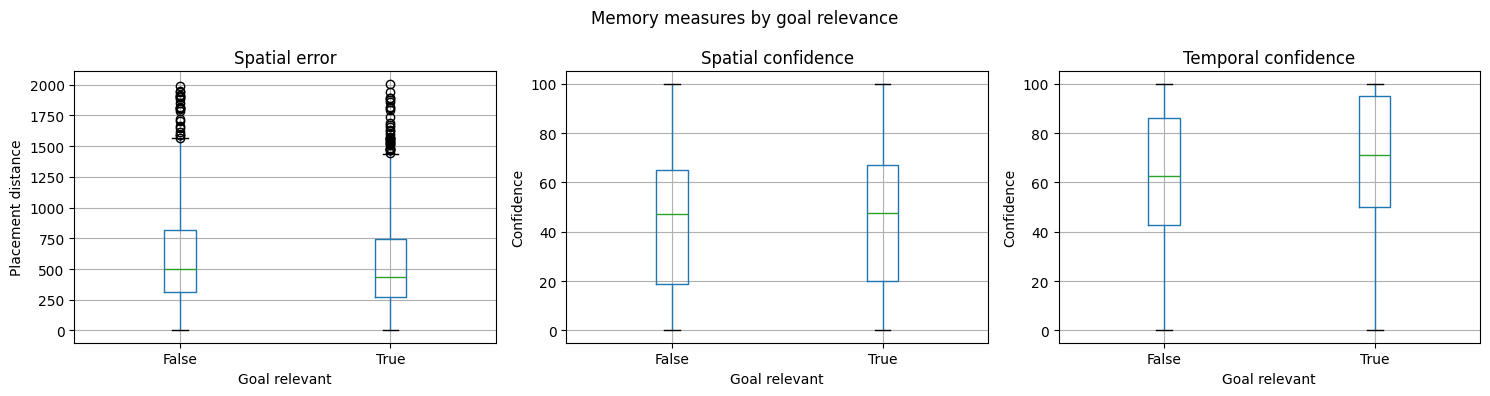

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

old.boxplot(column="placement_distance", by="is_relevant", ax=axes[0])
axes[0].set_title("Spatial error")
axes[0].set_xlabel("Goal relevant")
axes[0].set_ylabel("Placement distance")

old.boxplot(column="placement_confidence", by="is_relevant", ax=axes[1])
axes[1].set_title("Spatial confidence")
axes[1].set_xlabel("Goal relevant")
axes[1].set_ylabel("Confidence")

old.boxplot(column="temporal_confidence", by="is_relevant", ax=axes[2])
axes[2].set_title("Temporal confidence")
axes[2].set_xlabel("Goal relevant")
axes[2].set_ylabel("Confidence")

plt.suptitle("Memory measures by goal relevance")
plt.tight_layout()
plt.show()

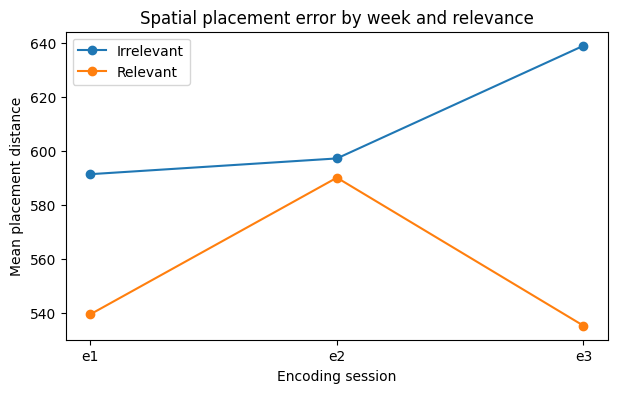

In [18]:
plot_df = (
    old.groupby(["encoding_session", "is_relevant"])["placement_distance"]
    .mean()
    .reset_index()
)

plot_df["label"] = plot_df["is_relevant"].map({True: "Relevant", False: "Irrelevant"})

fig, ax = plt.subplots(figsize=(7, 4))

for label, subdf in plot_df.groupby("label"):
    ax.plot(subdf["encoding_session"], subdf["placement_distance"], marker="o", label=label)

ax.set_title("Spatial placement error by week and relevance")
ax.set_xlabel("Encoding session")
ax.set_ylabel("Mean placement distance")
ax.legend()
plt.show()

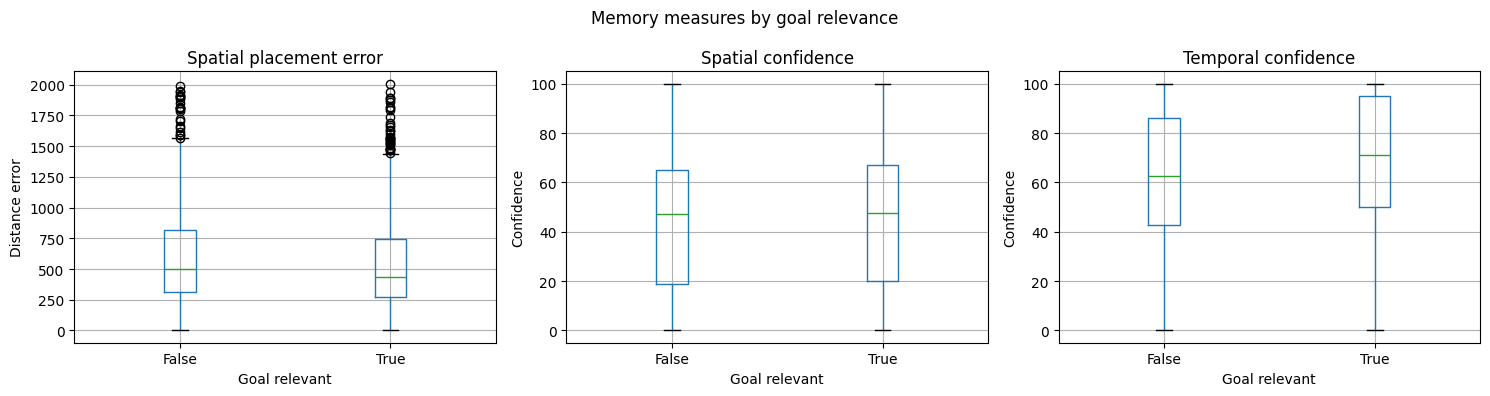

In [19]:
import matplotlib.pyplot as plt

old = mem_fmri[mem_fmri["is_old"]].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

old.boxplot(column="placement_distance", by="is_relevant", ax=axes[0])
axes[0].set_title("Spatial placement error")
axes[0].set_xlabel("Goal relevant")
axes[0].set_ylabel("Distance error")

old.boxplot(column="placement_confidence", by="is_relevant", ax=axes[1])
axes[1].set_title("Spatial confidence")
axes[1].set_xlabel("Goal relevant")
axes[1].set_ylabel("Confidence")

old.boxplot(column="temporal_confidence", by="is_relevant", ax=axes[2])
axes[2].set_title("Temporal confidence")
axes[2].set_xlabel("Goal relevant")
axes[2].set_ylabel("Confidence")

plt.suptitle("Memory measures by goal relevance")
plt.tight_layout()
plt.show()

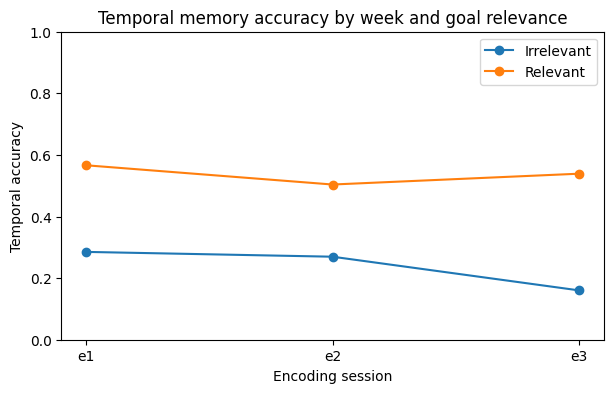

In [20]:
plot_df = (
    old.groupby(["encoding_session", "is_relevant"])["temporal_correct"]
    .mean()
    .reset_index()
)

plot_df["label"] = plot_df["is_relevant"].map({True: "Relevant", False: "Irrelevant"})

fig, ax = plt.subplots(figsize=(7, 4))

for label, subdf in plot_df.groupby("label"):
    ax.plot(subdf["encoding_session"], subdf["temporal_correct"], marker="o", label=label)

ax.set_ylim(0, 1)
ax.set_title("Temporal memory accuracy by week and goal relevance")
ax.set_xlabel("Encoding session")
ax.set_ylabel("Temporal accuracy")
ax.legend()
plt.show()

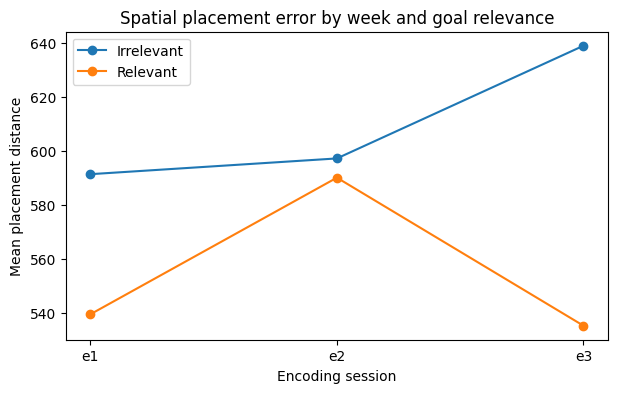

In [21]:
plot_df = (
    old.groupby(["encoding_session", "is_relevant"])["placement_distance"]
    .mean()
    .reset_index()
)

plot_df["label"] = plot_df["is_relevant"].map({True: "Relevant", False: "Irrelevant"})

fig, ax = plt.subplots(figsize=(7, 4))

for label, subdf in plot_df.groupby("label"):
    ax.plot(subdf["encoding_session"], subdf["placement_distance"], marker="o", label=label)

ax.set_title("Spatial placement error by week and goal relevance")
ax.set_xlabel("Encoding session")
ax.set_ylabel("Mean placement distance")
ax.legend()
plt.show()

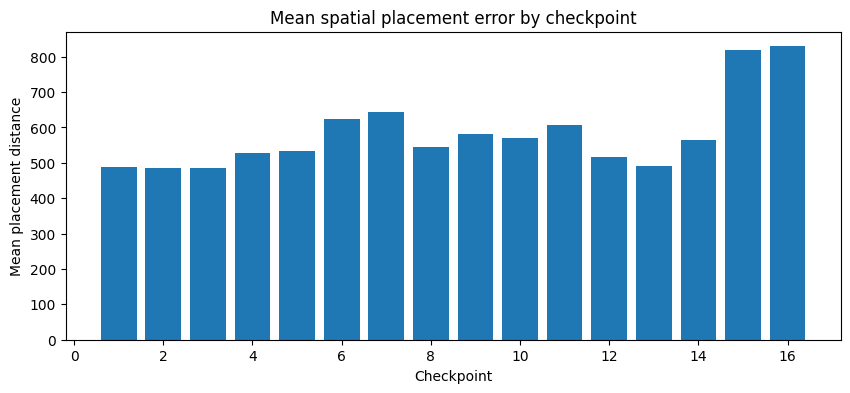

In [22]:
checkpoint_plot = checkpoint_summary.reset_index()
checkpoint_plot["checkpoint"] = checkpoint_plot["checkpoint"].astype(int)
checkpoint_plot = checkpoint_plot.sort_values("checkpoint")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(checkpoint_plot["checkpoint"], checkpoint_plot["mean_spatial_error"])
ax.set_title("Mean spatial placement error by checkpoint")
ax.set_xlabel("Checkpoint")
ax.set_ylabel("Mean placement distance")
plt.show()

In [23]:
subject_relevance = old.groupby(["participant_id", "is_relevant"]).agg(
    recognition_accuracy=("recognition_correct", "mean"),
    temporal_accuracy=("temporal_correct", "mean"),
    mean_spatial_error=("placement_distance", "mean"),
    mean_temporal_confidence=("temporal_confidence", "mean"),
).reset_index()

subject_wide = subject_relevance.pivot(
    index="participant_id",
    columns="is_relevant",
    values=["recognition_accuracy", "temporal_accuracy", "mean_spatial_error", "mean_temporal_confidence"]
)

subject_wide.columns = [
    f"{metric}_{'relevant' if rel else 'irrelevant'}"
    for metric, rel in subject_wide.columns
]

subject_wide["delta_temporal_accuracy"] = (
    subject_wide["temporal_accuracy_relevant"]
    - subject_wide["temporal_accuracy_irrelevant"]
)

subject_wide["delta_spatial_error"] = (
    subject_wide["mean_spatial_error_relevant"]
    - subject_wide["mean_spatial_error_irrelevant"]
)

subject_wide[[
    "temporal_accuracy_irrelevant",
    "temporal_accuracy_relevant",
    "delta_temporal_accuracy",
    "mean_spatial_error_irrelevant",
    "mean_spatial_error_relevant",
    "delta_spatial_error",
]].describe()

,temporal_accuracy_irrelevant,temporal_accuracy_relevant,delta_temporal_accuracy,mean_spatial_error_irrelevant,mean_spatial_error_relevant,delta_spatial_error
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,0.238281,0.536458,0.298177,609.297442,555.041591,-54.255851
std,0.113609,0.197359,0.244361,168.256994,139.146534,109.774694
min,0.041667,0.208333,-0.250000,371.606691,349.311691,-250.187781
25%,0.166667,0.416667,0.114583,468.531273,433.966309,-158.870537
50%,0.229167,0.458333,0.312500,599.300832,562.103428,-34.250211
75%,0.302083,0.750000,0.468750,743.989386,626.924103,10.597283
max,0.500000,0.875000,0.750000,960.698435,916.195237,123.576153


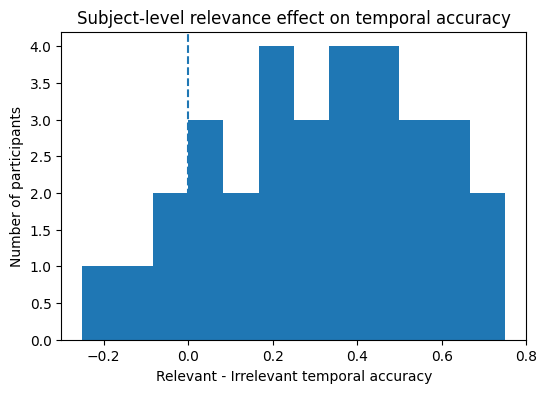

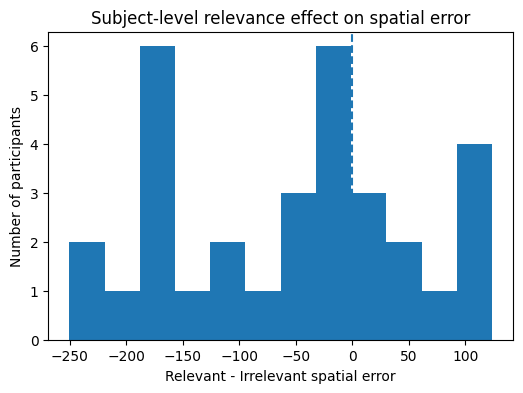

In [24]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(subject_wide["delta_temporal_accuracy"], bins=12)
ax.axvline(0, linestyle="--")
ax.set_title("Subject-level relevance effect on temporal accuracy")
ax.set_xlabel("Relevant - Irrelevant temporal accuracy")
ax.set_ylabel("Number of participants")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(subject_wide["delta_spatial_error"], bins=12)
ax.axvline(0, linestyle="--")
ax.set_title("Subject-level relevance effect on spatial error")
ax.set_xlabel("Relevant - Irrelevant spatial error")
ax.set_ylabel("Number of participants")
plt.show()

In [25]:
from scipy.stats import ttest_rel, wilcoxon

# Paired tests at participant level
temporal_rel = subject_wide["temporal_accuracy_relevant"]
temporal_irrel = subject_wide["temporal_accuracy_irrelevant"]

spatial_rel = subject_wide["mean_spatial_error_relevant"]
spatial_irrel = subject_wide["mean_spatial_error_irrelevant"]

recognition_rel = subject_wide["recognition_accuracy_relevant"]
recognition_irrel = subject_wide["recognition_accuracy_irrelevant"]

print("Temporal accuracy: relevant vs irrelevant")
print("Mean relevant:", temporal_rel.mean())
print("Mean irrelevant:", temporal_irrel.mean())
print("Mean delta:", (temporal_rel - temporal_irrel).mean())
print("Paired t-test:", ttest_rel(temporal_rel, temporal_irrel))
print("Wilcoxon:", wilcoxon(temporal_rel, temporal_irrel))

print("\nSpatial error: relevant vs irrelevant")
print("Mean relevant:", spatial_rel.mean())
print("Mean irrelevant:", spatial_irrel.mean())
print("Mean delta:", (spatial_rel - spatial_irrel).mean())
print("Paired t-test:", ttest_rel(spatial_rel, spatial_irrel))
print("Wilcoxon:", wilcoxon(spatial_rel, spatial_irrel))

print("\nRecognition accuracy: relevant vs irrelevant")
print("Mean relevant:", recognition_rel.mean())
print("Mean irrelevant:", recognition_irrel.mean())
print("Mean delta:", (recognition_rel - recognition_irrel).mean())
print("Paired t-test:", ttest_rel(recognition_rel, recognition_irrel))
print("Wilcoxon:", wilcoxon(recognition_rel, recognition_irrel))

Temporal accuracy: relevant vs irrelevant
Mean relevant: 0.5364583333333333
Mean irrelevant: 0.23828125
Mean delta: 0.2981770833333333
Paired t-test: TtestResult(statistic=np.float64(6.902687022653712), pvalue=np.float64(9.691841417262313e-08), df=np.int64(31))
Wilcoxon: WilcoxonResult(statistic=np.float64(21.5), pvalue=np.float64(9.004679014511265e-06))

Spatial error: relevant vs irrelevant
Mean relevant: 555.0415905027344
Mean irrelevant: 609.2974416188802
Mean delta: -54.255851116145834
Paired t-test: TtestResult(statistic=np.float64(-2.795885203430803), pvalue=np.float64(0.008806898166947639), df=np.int64(31))
Wilcoxon: WilcoxonResult(statistic=np.float64(130.0), pvalue=np.float64(0.01113977748900652))

Recognition accuracy: relevant vs irrelevant
Mean relevant: 0.8763020833333333
Mean irrelevant: 0.8411458333333333
Mean delta: 0.03515625
Paired t-test: TtestResult(statistic=np.float64(2.486571321258354), pvalue=np.float64(0.018491058841036283), df=np.int64(31))
Wilcoxon: Wilcoxon

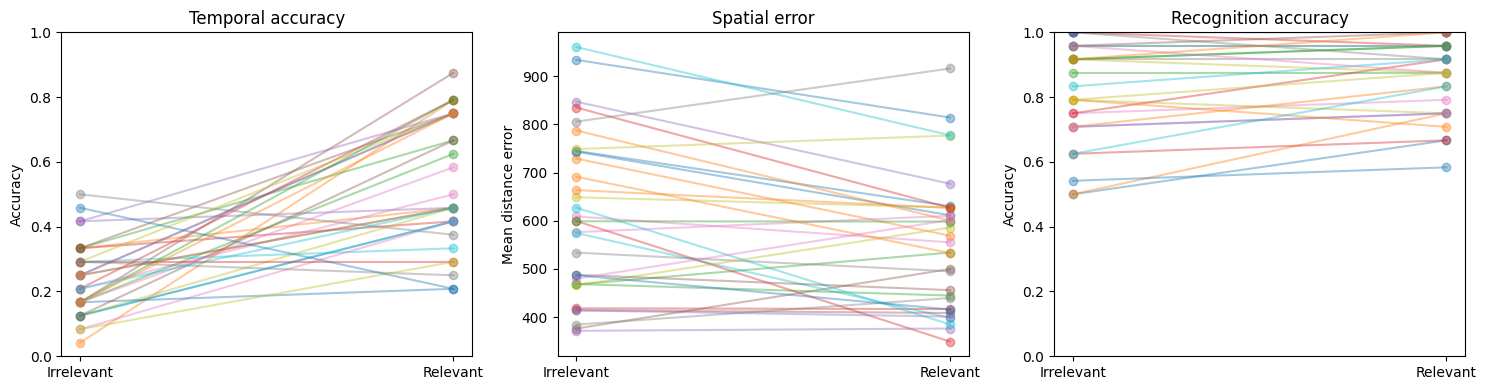

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Temporal accuracy
for _, row in subject_wide.iterrows():
    axes[0].plot([0, 1], [
        row["temporal_accuracy_irrelevant"],
        row["temporal_accuracy_relevant"]
    ], marker="o", alpha=0.4)

axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Irrelevant", "Relevant"])
axes[0].set_ylim(0, 1)
axes[0].set_title("Temporal accuracy")
axes[0].set_ylabel("Accuracy")

# Spatial error
for _, row in subject_wide.iterrows():
    axes[1].plot([0, 1], [
        row["mean_spatial_error_irrelevant"],
        row["mean_spatial_error_relevant"]
    ], marker="o", alpha=0.4)

axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Irrelevant", "Relevant"])
axes[1].set_title("Spatial error")
axes[1].set_ylabel("Mean distance error")

# Recognition
for _, row in subject_wide.iterrows():
    axes[2].plot([0, 1], [
        row["recognition_accuracy_irrelevant"],
        row["recognition_accuracy_relevant"]
    ], marker="o", alpha=0.4)

axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(["Irrelevant", "Relevant"])
axes[2].set_ylim(0, 1)
axes[2].set_title("Recognition accuracy")
axes[2].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

In [32]:
checkpoint_relevance = old.groupby(["checkpoint", "is_relevant"]).agg(
    n=("stimulus", "count"),
    recognition_accuracy=("recognition_correct", "mean"),
    temporal_accuracy=("temporal_correct", "mean"),
    mean_spatial_error=("placement_distance", "mean"),
    mean_spatial_confidence=("placement_confidence", "mean"),
).reset_index()

checkpoint_relevance["checkpoint"] = checkpoint_relevance["checkpoint"].astype(int)
checkpoint_relevance = checkpoint_relevance.sort_values(["checkpoint", "is_relevant"])

checkpoint_relevance

,checkpoint,is_relevant,n,recognition_accuracy,temporal_accuracy,mean_spatial_error,mean_spatial_confidence
0,1,False,45,0.800000,0.222222,532.688605,52.533333
1,1,True,51,0.882353,0.568627,451.163226,45.745098
16,2,False,45,0.755556,0.288889,564.003782,46.088889
17,2,True,51,0.941176,0.607843,418.456022,40.843137
18,3,False,51,0.901961,0.274510,498.815608,39.490196
19,3,True,45,0.911111,0.577778,468.451372,49.911111
20,4,False,51,0.803922,0.254902,570.476963,45.411765
21,4,True,45,0.911111,0.600000,481.569940,49.000000
22,5,False,45,0.933333,0.288889,503.842519,48.044444
23,5,True,51,0.843137,0.627451,560.255163,44.254902


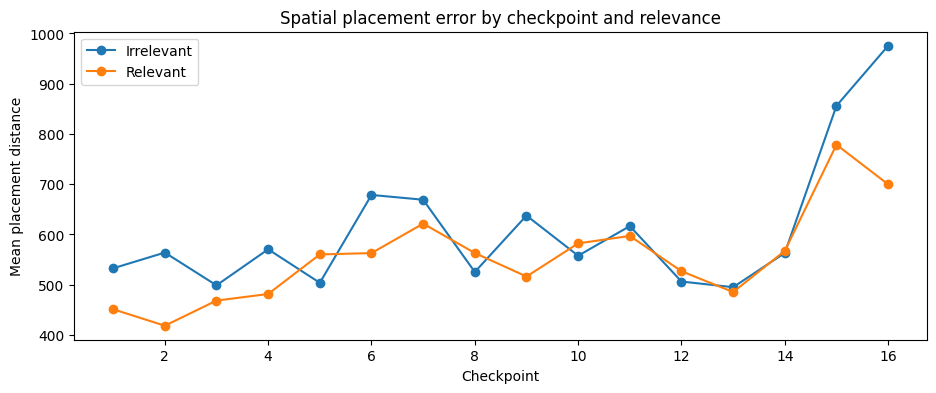

In [28]:
fig, ax = plt.subplots(figsize=(11, 4))

for rel, subdf in checkpoint_relevance.groupby("is_relevant"):
    label = "Relevant" if rel else "Irrelevant"
    ax.plot(
        subdf["checkpoint"],
        subdf["mean_spatial_error"],
        marker="o",
        label=label
    )

ax.set_title("Spatial placement error by checkpoint and relevance")
ax.set_xlabel("Checkpoint")
ax.set_ylabel("Mean placement distance")
ax.legend()
plt.show()

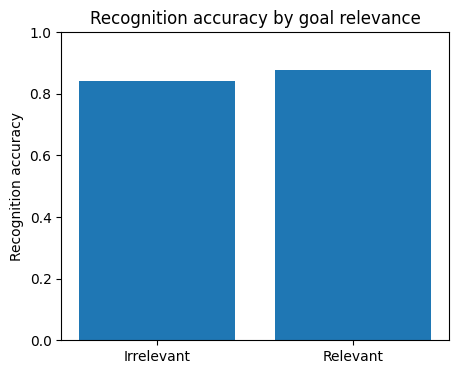

,is_relevant,recognition_correct,label
0,False,0.841146,Irrelevant
1,True,0.876302,Relevant


In [29]:
recognition_plot = (
    old.groupby("is_relevant")["recognition_correct"]
    .mean()
    .reset_index()
)

recognition_plot["label"] = recognition_plot["is_relevant"].map({
    False: "Irrelevant",
    True: "Relevant"
})

plt.figure(figsize=(5, 4))
plt.bar(recognition_plot["label"], recognition_plot["recognition_correct"])
plt.ylim(0, 1)
plt.ylabel("Recognition accuracy")
plt.title("Recognition accuracy by goal relevance")
plt.show()

recognition_plot

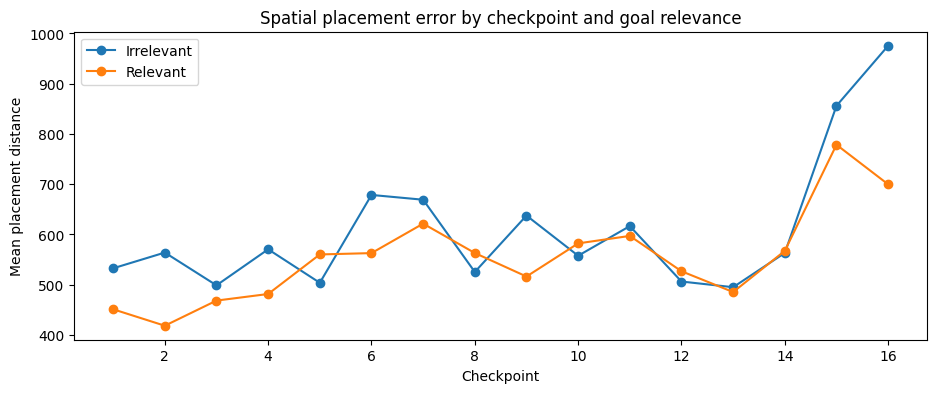

,checkpoint,is_relevant,n,recognition_accuracy,temporal_accuracy,mean_spatial_error,median_spatial_error,mean_spatial_confidence,mean_temporal_confidence
0,1,False,45,0.800000,0.222222,532.688605,448.7481,52.533333,59.866667
1,1,True,51,0.882353,0.568627,451.163226,308.0233,45.745098,63.588235
16,2,False,45,0.755556,0.288889,564.003782,421.2027,46.088889,61.155556
17,2,True,51,0.941176,0.607843,418.456022,335.8334,40.843137,69.666667
18,3,False,51,0.901961,0.274510,498.815608,431.1319,39.490196,63.137255
19,3,True,45,0.911111,0.577778,468.451372,431.6576,49.911111,73.288889
20,4,False,51,0.803922,0.254902,570.476963,457.2020,45.411765,61.156863
21,4,True,45,0.911111,0.600000,481.569940,387.1891,49.000000,66.444444
22,5,False,45,0.933333,0.288889,503.842519,441.9628,48.044444,63.777778
23,5,True,51,0.843137,0.627451,560.255163,401.3290,44.254902,69.156863


In [30]:
checkpoint_relevance = old.groupby(["checkpoint", "is_relevant"]).agg(
    n=("stimulus", "count"),
    recognition_accuracy=("recognition_correct", "mean"),
    temporal_accuracy=("temporal_correct", "mean"),
    mean_spatial_error=("placement_distance", "mean"),
    median_spatial_error=("placement_distance", "median"),
    mean_spatial_confidence=("placement_confidence", "mean"),
    mean_temporal_confidence=("temporal_confidence", "mean"),
).reset_index()

checkpoint_relevance["checkpoint"] = checkpoint_relevance["checkpoint"].astype(int)
checkpoint_relevance = checkpoint_relevance.sort_values(["checkpoint", "is_relevant"])

fig, ax = plt.subplots(figsize=(11, 4))

for rel, subdf in checkpoint_relevance.groupby("is_relevant"):
    label = "Relevant" if rel else "Irrelevant"
    ax.plot(
        subdf["checkpoint"],
        subdf["mean_spatial_error"],
        marker="o",
        label=label
    )

ax.set_title("Spatial placement error by checkpoint and goal relevance")
ax.set_xlabel("Checkpoint")
ax.set_ylabel("Mean placement distance")
ax.legend()
plt.show()

checkpoint_relevance

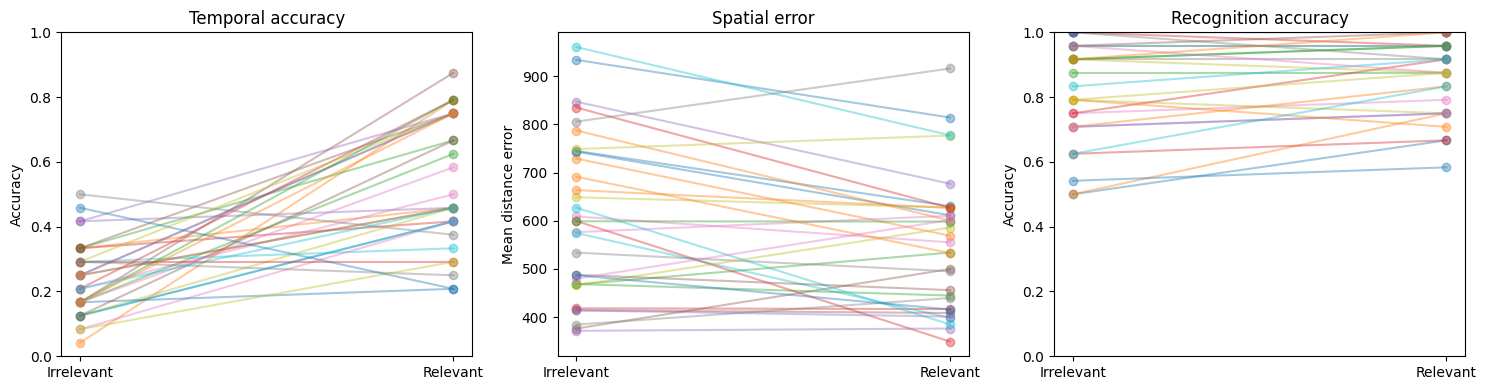

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Temporal accuracy
for _, row in subject_wide.iterrows():
    axes[0].plot(
        [0, 1],
        [row["temporal_accuracy_irrelevant"], row["temporal_accuracy_relevant"]],
        marker="o",
        alpha=0.4,
    )

axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Irrelevant", "Relevant"])
axes[0].set_ylim(0, 1)
axes[0].set_title("Temporal accuracy")
axes[0].set_ylabel("Accuracy")

# Spatial error
for _, row in subject_wide.iterrows():
    axes[1].plot(
        [0, 1],
        [row["mean_spatial_error_irrelevant"], row["mean_spatial_error_relevant"]],
        marker="o",
        alpha=0.4,
    )

axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Irrelevant", "Relevant"])
axes[1].set_title("Spatial error")
axes[1].set_ylabel("Mean distance error")

# Recognition accuracy
for _, row in subject_wide.iterrows():
    axes[2].plot(
        [0, 1],
        [row["recognition_accuracy_irrelevant"], row["recognition_accuracy_relevant"]],
        marker="o",
        alpha=0.4,
    )

axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(["Irrelevant", "Relevant"])
axes[2].set_ylim(0, 1)
axes[2].set_title("Recognition accuracy")
axes[2].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

In [33]:
from scipy.stats import ttest_rel, wilcoxon

print("Temporal accuracy")
print(ttest_rel(
    subject_wide["temporal_accuracy_relevant"],
    subject_wide["temporal_accuracy_irrelevant"]
))
print(wilcoxon(
    subject_wide["temporal_accuracy_relevant"],
    subject_wide["temporal_accuracy_irrelevant"]
))

print("\nSpatial error")
print(ttest_rel(
    subject_wide["mean_spatial_error_relevant"],
    subject_wide["mean_spatial_error_irrelevant"]
))
print(wilcoxon(
    subject_wide["mean_spatial_error_relevant"],
    subject_wide["mean_spatial_error_irrelevant"]
))

print("\nRecognition accuracy")
print(ttest_rel(
    subject_wide["recognition_accuracy_relevant"],
    subject_wide["recognition_accuracy_irrelevant"]
))
print(wilcoxon(
    subject_wide["recognition_accuracy_relevant"],
    subject_wide["recognition_accuracy_irrelevant"]
))

Temporal accuracy
TtestResult(statistic=np.float64(6.902687022653712), pvalue=np.float64(9.691841417262313e-08), df=np.int64(31))
WilcoxonResult(statistic=np.float64(21.5), pvalue=np.float64(9.004679014511265e-06))

Spatial error
TtestResult(statistic=np.float64(-2.795885203430803), pvalue=np.float64(0.008806898166947639), df=np.int64(31))
WilcoxonResult(statistic=np.float64(130.0), pvalue=np.float64(0.01113977748900652))

Recognition accuracy
TtestResult(statistic=np.float64(2.486571321258354), pvalue=np.float64(0.018491058841036283), df=np.int64(31))
WilcoxonResult(statistic=np.float64(57.0), pvalue=np.float64(0.023124271359225))


In [34]:
old = mem_fmri[mem_fmri["is_old"]].copy()

# Count trials by category, week, and relevance
cat_week_rel_counts = (
    old.groupby(["stim_cat", "encoding_session", "relevance"])
    .size()
    .reset_index(name="n")
    .sort_values(["stim_cat", "encoding_session", "relevance"])
)

cat_week_rel_counts

,stim_cat,encoding_session,relevance,n
0,drink,e1,nr,50
1,drink,e1,r,28
2,drink,e2,nr,30
3,drink,e2,r,68
4,drink,e3,nr,48
5,drink,e3,r,32
6,food,e1,nr,30
7,food,e1,r,68
8,food,e2,nr,48
9,food,e2,r,32


In [35]:
cat_week_rel_table = pd.pivot_table(
    old,
    index="stim_cat",
    columns=["encoding_session", "relevance"],
    values="stimulus",
    aggfunc="count",
    fill_value=0
)

cat_week_rel_table

encoding_session  e1      e2      e3    
relevance         nr   r  nr   r  nr   r
stim_cat                                
drink             50  28  30  68  48  32
food              30  68  48  32  50  28
maya              30  68  48  32  50  28
pirate            48  32  50  28  30  68
viking            50  28  30  68  48  32
wealth            48  32  50  28  30  68

In [36]:
# For each category, find which encoding session has relevant trials
category_week_mapping = (
    old[old["relevance"] == "r"]
    .groupby(["stim_cat", "encoding_session"])
    .size()
    .reset_index(name="n_relevant_trials")
    .sort_values(["stim_cat", "n_relevant_trials"], ascending=[True, False])
)

category_week_mapping

,stim_cat,encoding_session,n_relevant_trials
1,drink,e2,68
2,drink,e3,32
0,drink,e1,28
3,food,e1,68
4,food,e2,32
5,food,e3,28
6,maya,e1,68
7,maya,e2,32
8,maya,e3,28
11,pirate,e3,68


In [37]:
old = mem_fmri[mem_fmri["is_old"]].copy()

old["version"].value_counts(dropna=False)

version
v4    432
v2    384
v3    384
v1    336
Name: count, dtype: int64

In [38]:
old = mem_fmri[mem_fmri["is_old"]].copy()

participant_versions = (
    old.groupby("participant_id")["version"]
    .unique()
    .reset_index()
)

participant_versions["n_versions"] = participant_versions["version"].apply(len)
participant_versions

,participant_id,version,n_versions
0,10,[v1],1
1,12,[v2],1
2,13,[v2],1
3,14,[v3],1
4,15,[v3],1
5,16,[v4],1
6,17,[v4],1
7,18,[v1],1
8,19,[v1],1
9,20,[v2],1


In [39]:
pd.crosstab(old["participant_id"], old["version"])

version,v1,v2,v3,v4
participant_id,,,,
10,48,0,0,0
12,0,48,0,0
13,0,48,0,0
14,0,0,48,0
15,0,0,48,0
16,0,0,0,48
17,0,0,0,48
18,48,0,0,0
19,48,0,0,0


In [40]:
category_week_mapping = (
    old[old["relevance"] == "r"]
    .groupby(["version", "stim_cat", "encoding_session"])
    .size()
    .reset_index(name="n")
    .sort_values(["version", "encoding_session", "stim_cat"])
)

category_week_mapping

,version,stim_cat,encoding_session,n
0,v1,drink,e1,28
4,v1,viking,e1,28
3,v1,pirate,e2,28
5,v1,wealth,e2,28
1,v1,food,e3,28
2,v1,maya,e3,28
9,v2,pirate,e1,32
11,v2,wealth,e1,32
7,v2,food,e2,32
8,v2,maya,e2,32


In [41]:
mapping_matrix = (
    category_week_mapping
    .pivot_table(
        index=["version", "stim_cat"],
        columns="encoding_session",
        values="n",
        fill_value=0
    )
)

mapping_matrix

encoding_session    e1    e2    e3
version stim_cat                  
v1      drink     28.0   0.0   0.0
        food       0.0   0.0  28.0
        maya       0.0   0.0  28.0
        pirate     0.0  28.0   0.0
        viking    28.0   0.0   0.0
        wealth     0.0  28.0   0.0
v2      drink      0.0   0.0  32.0
        food       0.0  32.0   0.0
        maya       0.0  32.0   0.0
        pirate    32.0   0.0   0.0
        viking     0.0   0.0  32.0
        wealth    32.0   0.0   0.0
v3      drink      0.0  32.0   0.0
        food      32.0   0.0   0.0
        maya      32.0   0.0   0.0
        pirate     0.0   0.0  32.0
        viking     0.0  32.0   0.0
        wealth     0.0   0.0  32.0
v4      drink      0.0  36.0   0.0
        food      36.0   0.0   0.0
        maya      36.0   0.0   0.0
        pirate     0.0   0.0  36.0
        viking     0.0  36.0   0.0
        wealth     0.0   0.0  36.0

In [43]:
# Build schema-predicted week from relevant trials
category_to_schema_week = (
    old[old["relevance"] == "r"]
    .groupby(["version", "stim_cat"])["encoding_session"]
    .agg(lambda x: x.mode().iloc[0])
    .to_dict()
)

week_to_temporal_response = {
    "e1": "two_weeks",
    "e2": "one_week",
    "e3": "yesterday",
}

old["schema_predicted_encoding_session"] = old.apply(
    lambda row: category_to_schema_week.get((row["version"], row["stim_cat"])),
    axis=1
)

old["schema_predicted_temporal_response"] = old["schema_predicted_encoding_session"].map(
    week_to_temporal_response
)

old["schema_congruent"] = old["schema_predicted_encoding_session"].eq(old["encoding_session"])

old["followed_schema_response"] = old["temporal_response"].eq(
    old["schema_predicted_temporal_response"]
)

old["true_temporal_correct"] = old["temporal_response"].eq(
    old["expected_temporal_response"]
)

pd.crosstab(
    old["is_relevant"],
    old["schema_congruent"],
    margins=True
)

schema_congruent,False,True,All
is_relevant,,,
False,768,0,768
True,0,768,768
All,768,768,1536


In [44]:
schema_bias_summary = old.groupby(["is_relevant", "schema_congruent"]).agg(
    n=("stimulus", "count"),
    true_temporal_accuracy=("true_temporal_correct", "mean"),
    schema_response_rate=("followed_schema_response", "mean"),
    recognition_accuracy=("recognition_correct", "mean"),
    mean_spatial_error=("placement_distance", "mean"),
    mean_temporal_confidence=("temporal_confidence", "mean"),
).reset_index()

schema_bias_summary

,is_relevant,schema_congruent,n,true_temporal_accuracy,schema_response_rate,recognition_accuracy,mean_spatial_error,mean_temporal_confidence
0,False,False,768,0.238281,0.433594,0.841146,609.297442,61.532552
1,True,True,768,0.536458,0.536458,0.876302,555.041591,66.148438


In [45]:
pd.crosstab(
    [old["version"], old["stim_cat"]],
    old["temporal_response"],
    normalize="index"
)

temporal_response     never  one_week  two_weeks  yesterday
version stim_cat                                           
v1      drink      0.071429  0.178571   0.589286   0.160714
        food       0.160714  0.303571   0.160714   0.375000
        maya       0.232143  0.196429   0.089286   0.482143
        pirate     0.142857  0.589286   0.250000   0.017857
        viking     0.321429  0.214286   0.410714   0.053571
        wealth     0.071429  0.464286   0.375000   0.089286
v2      drink      0.109375  0.140625   0.203125   0.546875
        food       0.156250  0.375000   0.328125   0.140625
        maya       0.093750  0.562500   0.265625   0.078125
        pirate     0.125000  0.218750   0.468750   0.187500
        viking     0.250000  0.171875   0.156250   0.421875
        wealth     0.078125  0.328125   0.390625   0.203125
v3      drink      0.125000  0.484375   0.218750   0.171875
        food       0.078125  0.234375   0.515625   0.171875
        maya       0.093750  0.171875   0.656250   0.078125
        pirate     0.062500  0.296875   0.140625   0.500000
        viking     0.218750  0.359375   0.250000   0.171875
        wealth     0.062500  0.234375   0.187500   0.515625
v4      drink      0.111111  0.569444   0.194444   0.125000
        food       0.208333  0.208333   0.486111   0.097222
        maya       0.222222  0.194444   0.513889   0.069444
        pirate     0.250000  0.194444   0.180556   0.375000
        viking     0.402778  0.402778   0.083333   0.111111
        wealth     0.125000  0.180556   0.111111   0.583333

In [46]:
irrelevant = old[old["is_relevant"] == False].copy()

irrelevant.groupby("encoding_session").agg(
    n=("stimulus", "count"),
    true_temporal_accuracy=("true_temporal_correct", "mean"),
    schema_response_rate=("followed_schema_response", "mean"),
    recognition_accuracy=("recognition_correct", "mean"),
    mean_spatial_error=("placement_distance", "mean"),
    mean_temporal_confidence=("temporal_confidence", "mean"),
)

,n,true_temporal_accuracy,schema_response_rate,recognition_accuracy,mean_spatial_error,mean_temporal_confidence
encoding_session,,,,,,
e1,256,0.285156,0.406250,0.859375,591.489083,61.996094
e2,256,0.269531,0.453125,0.863281,597.325896,61.546875
e3,256,0.160156,0.441406,0.800781,639.077345,61.054688


In [47]:
irrelevant.groupby("true_temporal_correct").agg(
    n=("stimulus", "count"),
    recognition_accuracy=("recognition_correct", "mean"),
    mean_spatial_error=("placement_distance", "mean"),
    median_spatial_error=("placement_distance", "median"),
    mean_spatial_confidence=("placement_confidence", "mean"),
    mean_temporal_confidence=("temporal_confidence", "mean"),
)

,n,recognition_accuracy,mean_spatial_error,median_spatial_error,mean_spatial_confidence,mean_temporal_confidence
true_temporal_correct,,,,,,
False,585,0.791453,644.243478,541.4937,46.635897,63.430769
True,183,1.000000,497.584703,440.4031,38.852459,55.464481


In [48]:
old_no_schema = old[~old["followed_schema_response"]].copy()

old_no_schema.groupby("is_relevant").agg(
    n=("stimulus", "count"),
    true_temporal_accuracy=("true_temporal_correct", "mean"),
    recognition_accuracy=("recognition_correct", "mean"),
    mean_spatial_error=("placement_distance", "mean"),
    median_spatial_error=("placement_distance", "median"),
    mean_spatial_confidence=("placement_confidence", "mean"),
    mean_temporal_confidence=("temporal_confidence", "mean"),
)

,n,true_temporal_accuracy,recognition_accuracy,mean_spatial_error,median_spatial_error,mean_spatial_confidence,mean_temporal_confidence
is_relevant,,,,,,,
False,435,0.42069,0.721839,713.912556,612.61980,48.468966,58.832184
True,356,0.00000,0.738764,707.816692,605.55635,49.325843,60.143258


In [49]:
irrelevant = old[old["is_relevant"] == False].copy()

irrelevant["response_type"] = np.select(
    [
        irrelevant["true_temporal_correct"],
        irrelevant["followed_schema_response"],
        irrelevant["temporal_response"].eq("never")
    ],
    [
        "true_week",
        "schema_week",
        "never"
    ],
    default="other_wrong_week"
)

irrelevant["response_type"].value_counts(normalize=True)

response_type
schema_week         0.433594
true_week           0.238281
never               0.175781
other_wrong_week    0.152344
Name: proportion, dtype: float64

In [50]:
irrelevant = old[old["is_relevant"] == False].copy()

participant_schema = irrelevant.groupby("participant_id").agg(
    n=("stimulus", "count"),
    irrelevant_true_temporal_accuracy=("true_temporal_correct", "mean"),
    irrelevant_schema_response_rate=("followed_schema_response", "mean"),
    irrelevant_recognition_accuracy=("recognition_correct", "mean"),
    irrelevant_mean_spatial_error=("placement_distance", "mean"),
).reset_index()

participant_schema["schema_resistance_score"] = (
    participant_schema["irrelevant_true_temporal_accuracy"]
    - participant_schema["irrelevant_schema_response_rate"]
)

participant_schema.sort_values("schema_resistance_score", ascending=False)

,participant_id,n,irrelevant_true_temporal_accuracy,irrelevant_schema_response_rate,irrelevant_recognition_accuracy,irrelevant_mean_spatial_error,schema_resistance_score
30,50,24,0.458333,0.166667,1.000000,487.068949,0.291667
4,15,24,0.416667,0.208333,1.000000,847.252250,0.208333
17,31,24,0.500000,0.291667,1.000000,384.553490,0.208333
1,12,24,0.333333,0.125000,0.500000,729.138250,0.208333
23,42,24,0.291667,0.166667,0.625000,835.071167,0.125000
3,14,24,0.333333,0.333333,1.000000,418.302896,0.000000
10,21,24,0.250000,0.250000,0.708333,745.001067,0.000000
27,47,24,0.291667,0.333333,0.958333,805.930950,-0.041667
20,36,24,0.166667,0.208333,0.541667,934.081540,-0.041667
24,43,24,0.416667,0.500000,1.000000,413.940463,-0.083333


In [51]:
median_score = participant_schema["schema_resistance_score"].median()

participant_schema["schema_resistance_group"] = np.where(
    participant_schema["schema_resistance_score"] >= median_score,
    "high_resistance",
    "low_resistance"
)

participant_schema[[
    "participant_id",
    "irrelevant_true_temporal_accuracy",
    "irrelevant_schema_response_rate",
    "schema_resistance_score",
    "schema_resistance_group"
]].sort_values("schema_resistance_score", ascending=False)

,participant_id,irrelevant_true_temporal_accuracy,irrelevant_schema_response_rate,schema_resistance_score,schema_resistance_group
30,50,0.458333,0.166667,0.291667,high_resistance
4,15,0.416667,0.208333,0.208333,high_resistance
17,31,0.500000,0.291667,0.208333,high_resistance
1,12,0.333333,0.125000,0.208333,high_resistance
23,42,0.291667,0.166667,0.125000,high_resistance
3,14,0.333333,0.333333,0.000000,high_resistance
10,21,0.250000,0.250000,0.000000,high_resistance
27,47,0.291667,0.333333,-0.041667,high_resistance
20,36,0.166667,0.208333,-0.041667,high_resistance
24,43,0.416667,0.500000,-0.083333,high_resistance


In [52]:
old_with_group = old.merge(
    participant_schema[["participant_id", "schema_resistance_group", "schema_resistance_score"]],
    on="participant_id",
    how="left"
)

In [53]:
relevant_only = old_with_group[old_with_group["is_relevant"] == True].copy()

relevant_only.groupby("schema_resistance_group").agg(
    n=("stimulus", "count"),
    relevant_temporal_accuracy=("true_temporal_correct", "mean"),
    relevant_recognition_accuracy=("recognition_correct", "mean"),
    relevant_mean_spatial_error=("placement_distance", "mean"),
    relevant_mean_temporal_confidence=("temporal_confidence", "mean"),
)

,n,relevant_temporal_accuracy,relevant_recognition_accuracy,relevant_mean_spatial_error,relevant_mean_temporal_confidence
schema_resistance_group,,,,,
high_resistance,432,0.456019,0.854167,576.218438,60.569444
low_resistance,336,0.639881,0.904762,527.814215,73.321429


In [54]:
relevant_by_participant = relevant_only.groupby("participant_id").agg(
    relevant_temporal_accuracy=("true_temporal_correct", "mean"),
    relevant_recognition_accuracy=("recognition_correct", "mean"),
    relevant_mean_spatial_error=("placement_distance", "mean"),
    relevant_mean_temporal_confidence=("temporal_confidence", "mean"),
).reset_index()

participant_level = participant_schema.merge(
    relevant_by_participant,
    on="participant_id",
    how="inner"
)

participant_level[[
    "schema_resistance_score",
    "relevant_temporal_accuracy",
    "relevant_recognition_accuracy",
    "relevant_mean_spatial_error",
    "relevant_mean_temporal_confidence",
]].corr()

,schema_resistance_score,relevant_temporal_accuracy,relevant_recognition_accuracy,relevant_mean_spatial_error,relevant_mean_temporal_confidence
schema_resistance_score,1.000000,-0.601286,-0.192325,0.108919,-0.286171
relevant_temporal_accuracy,-0.601286,1.000000,0.450886,-0.434658,0.143898
relevant_recognition_accuracy,-0.192325,0.450886,1.000000,-0.501522,0.016840
relevant_mean_spatial_error,0.108919,-0.434658,-0.501522,1.000000,-0.185139
relevant_mean_temporal_confidence,-0.286171,0.143898,0.016840,-0.185139,1.000000


In [55]:
irrelevant_seen = old[
    (old["is_relevant"] == False) &
    (old["recognition_response"] == "seen")
].copy()

irrelevant_seen["response_type"] = np.select(
    [
        irrelevant_seen["true_temporal_correct"],
        irrelevant_seen["followed_schema_response"],
        irrelevant_seen["temporal_response"].eq("never")
    ],
    [
        "true_week",
        "schema_week",
        "never"
    ],
    default="other_wrong_week"
)

irrelevant_seen["response_type"].value_counts(normalize=True)

response_type
schema_week         0.513932
true_week           0.283282
other_wrong_week    0.176471
never               0.026316
Name: proportion, dtype: float64

In [56]:
irrelevant_all = old[old["is_relevant"] == False].copy()

irrelevant_all["response_type"] = np.select(
    [
        irrelevant_all["true_temporal_correct"],
        irrelevant_all["followed_schema_response"],
        irrelevant_all["temporal_response"].eq("never")
    ],
    [
        "true_week",
        "schema_week",
        "never"
    ],
    default="other_wrong_week"
)

print("All irrelevant trials:")
print(irrelevant_all["response_type"].value_counts(normalize=True))

print("\nRecognized irrelevant trials only:")
print(irrelevant_seen["response_type"].value_counts(normalize=True))

All irrelevant trials:
response_type
schema_week         0.433594
true_week           0.238281
never               0.175781
other_wrong_week    0.152344
Name: proportion, dtype: float64

Recognized irrelevant trials only:
response_type
schema_week         0.513932
true_week           0.283282
other_wrong_week    0.176471
never               0.026316
Name: proportion, dtype: float64


In [57]:
irrelevant_seen.groupby("response_type").agg(
    n=("stimulus", "count"),
    mean_spatial_error=("placement_distance", "mean"),
    median_spatial_error=("placement_distance", "median"),
    mean_spatial_confidence=("placement_confidence", "mean"),
    mean_temporal_confidence=("temporal_confidence", "mean"),
)

,n,mean_spatial_error,median_spatial_error,mean_spatial_confidence,mean_temporal_confidence
response_type,,,,,
never,17,1069.826859,1147.1910,60.588235,57.764706
other_wrong_week,114,551.144459,483.8428,39.526316,51.964912
schema_week,332,469.494291,423.1779,40.084337,65.253012
true_week,183,497.584703,440.4031,38.852459,55.464481


In [58]:
irrelevant_seen.groupby("response_type").agg(
    n=("stimulus", "count"),
    mean_spatial_error=("placement_distance", "mean"),
    median_spatial_error=("placement_distance", "median"),
    mean_spatial_confidence=("placement_confidence", "mean"),
    mean_temporal_confidence=("temporal_confidence", "mean"),
)

,n,mean_spatial_error,median_spatial_error,mean_spatial_confidence,mean_temporal_confidence
response_type,,,,,
never,17,1069.826859,1147.1910,60.588235,57.764706
other_wrong_week,114,551.144459,483.8428,39.526316,51.964912
schema_week,332,469.494291,423.1779,40.084337,65.253012
true_week,183,497.584703,440.4031,38.852459,55.464481


In [59]:
irrelevant_seen.groupby("response_type")[
    ["placement_distance", "placement_confidence", "temporal_confidence"]
].describe()

placement_distance                                       \
                              count         mean         std         min   
response_type                                                              
never                          17.0  1069.826859  386.355206  252.281500   
other_wrong_week              114.0   551.144459  394.171699    0.952219   
schema_week                   332.0   469.494291  303.475059    1.487521   
true_week                     183.0   497.584703  356.654426    3.158500   

                                                                \
                         25%        50%          75%       max   
response_type                                                    
never             944.151200  1147.1910  1225.522000  1898.771   
other_wrong_week  327.022225   483.8428   702.790125  1938.469   
schema_week       273.469100   423.1779   617.484575  1784.741   
true_week         254.456350   440.4031   648.408300  1987.496   

                 placement_confidence             ...                 \
                                count       mean  ...     75%    max   
response_type                                     ...                  
never                            17.0  60.588235  ...  100.00  100.0   
other_wrong_week                114.0  39.526316  ...   58.50  100.0   
schema_week                     332.0  40.084337  ...   57.25  100.0   
true_week                       183.0  38.852459  ...   51.00  100.0   

                 temporal_confidence                                         \
                               count       mean        std  min   25%   50%   
response_type                                                                 
never                           17.0  57.764706  43.394310  0.0  18.0  50.0   
other_wrong_week               114.0  51.964912  27.595988  0.0  30.0  50.0   
schema_week                    332.0  65.253012  27.468342  0.0  50.0  69.5   
true_week                      183.0  55.464481  28.141081  0.0  35.0  52.0   

                                 
                     75%    max  
response_type                    
never             100.00  100.0  
other_wrong_week   70.75  100.0  
schema_week        90.00  100.0  
true_week          77.50  100.0  

[4 rows x 24 columns]

In [60]:
recognized_old = old[old["recognition_response"] == "seen"].copy()

recognized_old.groupby("is_relevant").agg(
    n=("stimulus", "count"),
    true_temporal_accuracy=("true_temporal_correct", "mean"),
    schema_response_rate=("followed_schema_response", "mean"),
    mean_spatial_error=("placement_distance", "mean"),
    median_spatial_error=("placement_distance", "median"),
    mean_temporal_confidence=("temporal_confidence", "mean"),
    mean_spatial_confidence=("placement_confidence", "mean"),
)

,n,true_temporal_accuracy,schema_response_rate,mean_spatial_error,median_spatial_error,mean_temporal_confidence,mean_spatial_confidence
is_relevant,,,,,,,
False,646,0.283282,0.513932,507.658870,445.42985,59.938080,40.176471
True,673,0.609212,0.609212,470.343435,404.93300,65.843982,42.971768


In [61]:
pd.crosstab(
    recognized_old["is_relevant"],
    recognized_old["response_type"] if "response_type" in recognized_old.columns else recognized_old["temporal_response"],
    normalize="index"
)

temporal_response,never,one_week,two_weeks,yesterday
is_relevant,,,,
False,0.026316,0.352941,0.351393,0.269350
True,0.023774,0.349183,0.344725,0.282318


In [62]:
recognized_old["response_type"] = np.select(
    [
        recognized_old["true_temporal_correct"],
        recognized_old["followed_schema_response"],
        recognized_old["temporal_response"].eq("never"),
    ],
    [
        "true_week",
        "schema_week",
        "never",
    ],
    default="other_wrong_week",
)

In [63]:
irrelevant_seen.groupby("response_type").agg(
    n=("stimulus", "count"),
    mean_spatial_error=("placement_distance", "mean"),
    median_spatial_error=("placement_distance", "median"),
    mean_spatial_confidence=("placement_confidence", "mean"),
    mean_temporal_confidence=("temporal_confidence", "mean"),
)

,n,mean_spatial_error,median_spatial_error,mean_spatial_confidence,mean_temporal_confidence
response_type,,,,,
never,17,1069.826859,1147.1910,60.588235,57.764706
other_wrong_week,114,551.144459,483.8428,39.526316,51.964912
schema_week,332,469.494291,423.1779,40.084337,65.253012
true_week,183,497.584703,440.4031,38.852459,55.464481


In [64]:
irrelevant_old = old[old["is_relevant"] == False].copy()

irrelevant_old["memory_label"] = np.select(
    [
        irrelevant_old["recognition_response"].eq("not_seen"),
        irrelevant_old["true_temporal_correct"],
        irrelevant_old["followed_schema_response"],
    ],
    [
        "forgotten",
        "true_week",
        "schema_week",
    ],
    default="other_wrong_week"
)

counts_by_subject = pd.crosstab(
    irrelevant_old["participant_id"],
    irrelevant_old["memory_label"]
)

counts_by_subject

memory_label,forgotten,other_wrong_week,schema_week,true_week
participant_id,,,,
10,12,4,5,3
12,12,1,3,8
13,3,3,14,4
14,0,8,8,8
15,0,9,5,10
16,0,1,19,4
17,6,6,7,5
18,2,0,16,6
19,5,6,10,3


In [65]:
counts_by_subject.describe()

memory_label,forgotten,other_wrong_week,schema_week,true_week
count,32.000000,32.000000,32.000000,32.000000
mean,3.812500,4.093750,10.375000,5.718750
std,3.805238,2.607178,4.419531,2.726624
min,0.000000,0.000000,3.000000,1.000000
25%,0.750000,2.000000,7.000000,4.000000
50%,2.000000,4.000000,10.500000,5.500000
75%,6.250000,6.000000,13.250000,7.250000
max,12.000000,9.000000,19.000000,12.000000


In [66]:
valid_subjects = counts_by_subject[
    (counts_by_subject.get("true_week", 0) >= 3) &
    (counts_by_subject.get("schema_week", 0) >= 3)
].index.tolist()

valid_subjects, len(valid_subjects)

([10,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  23,
  25,
  26,
  27,
  31,
  34,
  35,
  36,
  37,
  41,
  42,
  43,
  44,
  45,
  47,
  49,
  50,
  51],
 29)

In [67]:
irrelevant_seen = old[
    (old["is_relevant"] == False) &
    (old["recognition_response"] == "seen")
].copy()

irrelevant_seen["response_type"] = np.select(
    [
        irrelevant_seen["true_temporal_correct"],
        irrelevant_seen["followed_schema_response"],
        irrelevant_seen["temporal_response"].eq("never"),
    ],
    [
        "true_week",
        "schema_week",
        "never",
    ],
    default="other_wrong_week",
)

summary_response_type = irrelevant_seen.groupby("response_type").agg(
    n=("stimulus", "count"),
    proportion=("stimulus", lambda x: len(x) / len(irrelevant_seen)),
    mean_spatial_error=("placement_distance", "mean"),
    median_spatial_error=("placement_distance", "median"),
    mean_spatial_confidence=("placement_confidence", "mean"),
    mean_temporal_confidence=("temporal_confidence", "mean"),
).sort_values("proportion", ascending=False)

summary_response_type

,n,proportion,mean_spatial_error,median_spatial_error,mean_spatial_confidence,mean_temporal_confidence
response_type,,,,,,
schema_week,332,0.513932,469.494291,423.1779,40.084337,65.253012
true_week,183,0.283282,497.584703,440.4031,38.852459,55.464481
other_wrong_week,114,0.176471,551.144459,483.8428,39.526316,51.964912
never,17,0.026316,1069.826859,1147.1910,60.588235,57.764706


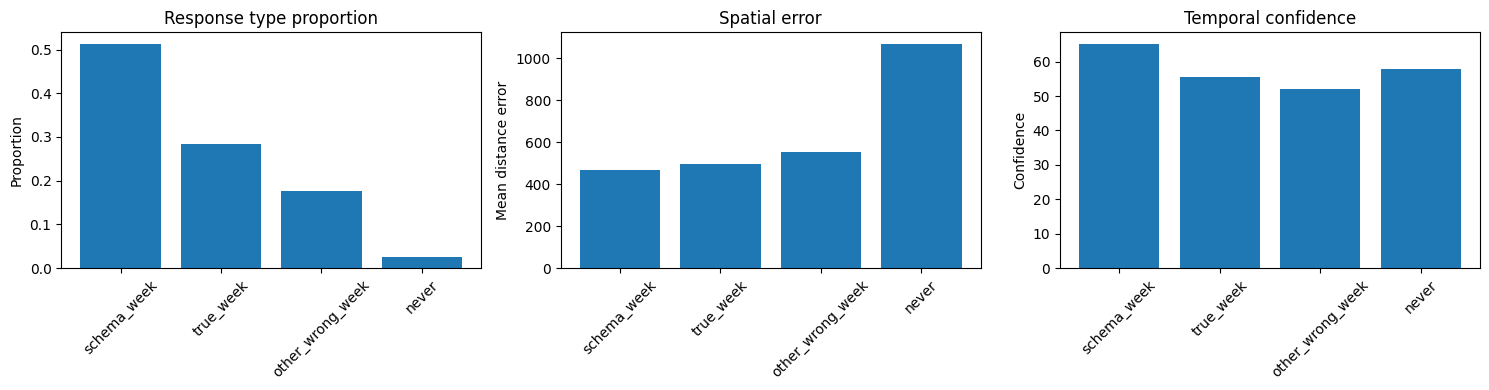

In [68]:
import matplotlib.pyplot as plt

order = ["schema_week", "true_week", "other_wrong_week", "never"]
plot_df = summary_response_type.loc[[x for x in order if x in summary_response_type.index]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(plot_df.index, plot_df["proportion"])
axes[0].set_title("Response type proportion")
axes[0].set_ylabel("Proportion")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(plot_df.index, plot_df["mean_spatial_error"])
axes[1].set_title("Spatial error")
axes[1].set_ylabel("Mean distance error")
axes[1].tick_params(axis="x", rotation=45)

axes[2].bar(plot_df.index, plot_df["mean_temporal_confidence"])
axes[2].set_title("Temporal confidence")
axes[2].set_ylabel("Confidence")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()